# Fake News Classifier - Exploratory Data Analysis
## Part 1: Data Exploration and Visualization

### 1. Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

### 2. Load and Inspect Data

In [16]:
df = pd.read_csv('fake_and_real_news.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (9900, 2)

First 5 rows:


,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [17]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9900 entries, 0 to 9899
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    9900 non-null   object
 1   label   9900 non-null   object
dtypes: object(2)
memory usage: 154.8+ KB


In [18]:
print("Missing Values:")
print(df.isnull().sum())
print("\nMissing Values Percentage:")
print((df.isnull().sum() / len(df)) * 100)

Missing Values:
Text     0
label    0
dtype: int64

Missing Values Percentage:
Text     0.0
label    0.0
dtype: float64


In [19]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage of duplicates: {(duplicates / len(df)) * 100:.2f}%")

Number of duplicate rows: 35
Percentage of duplicates: 0.35%


In [20]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Text,label
count,9900,9900
unique,9865,2
top,Highlights: The Trump presidency on April 13 a...,Fake
freq,8,5000


### 3. Label Distribution Analysis

In [21]:
label_counts = df['label'].value_counts()
print("Label Distribution:")
print(label_counts)
print("\nPercentage Distribution:")
print((label_counts / len(df)) * 100)

Label Distribution:
label
Fake    5000
Real    4900
Name: count, dtype: int64

Percentage Distribution:
label
Fake    50.505051
Real    49.494949
Name: count, dtype: float64


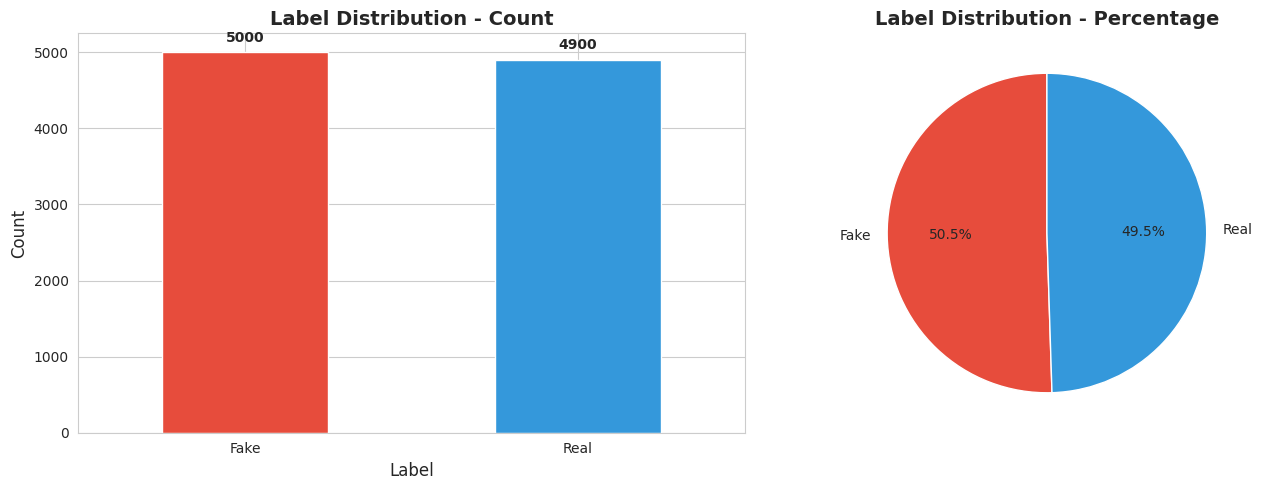


Dataset is BALANCED (ratio: 0.98)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
label_counts.plot(kind='bar', ax=ax1, color=['#e74c3c', '#3498db'])
ax1.set_title('Label Distribution - Count', fontsize=14, fontweight='bold')
ax1.set_xlabel('Label', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
for i, v in enumerate(label_counts):
    ax1.text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')

ax2 = axes[1]
colors = ['#e74c3c', '#3498db']
label_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90, colors=colors)
ax2.set_title('Label Distribution - Percentage', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

ratio = label_counts.min() / label_counts.max()
if ratio > 0.8:
    print(f"\nDataset is BALANCED (ratio: {ratio:.2f})")
else:
    print(f"\nDataset is IMBALANCED (ratio: {ratio:.2f})")

### 4. Text Length Analysis

In [23]:
df['text_length'] = df['Text'].apply(len)

df['word_count'] = df['Text'].apply(lambda x: len(str(x).split()))

print("Text Length Statistics by Label:")
print(df.groupby('label')[['text_length', 'word_count']].describe())

Text Length Statistics by Label:
      text_length                                                           \
            count         mean          std    min     25%     50%     75%   
label                                                                        
Fake       5000.0  2691.300200   914.560549  316.0  2104.0  2498.0  3103.0   
Real       4900.0  2484.622449  1751.989932  219.0   833.5  2401.0  3479.0   

               word_count                                                     \
           max      count        mean         std   min    25%    50%    75%   
label                                                                          
Fake   20356.0     5000.0  449.408800  149.539806  46.0  354.0  419.0  517.0   
Real   29849.0     4900.0  396.130816  282.562195  35.0  133.0  382.5  554.0   

               
          max  
label          
Fake   3927.0  
Real   5181.0  


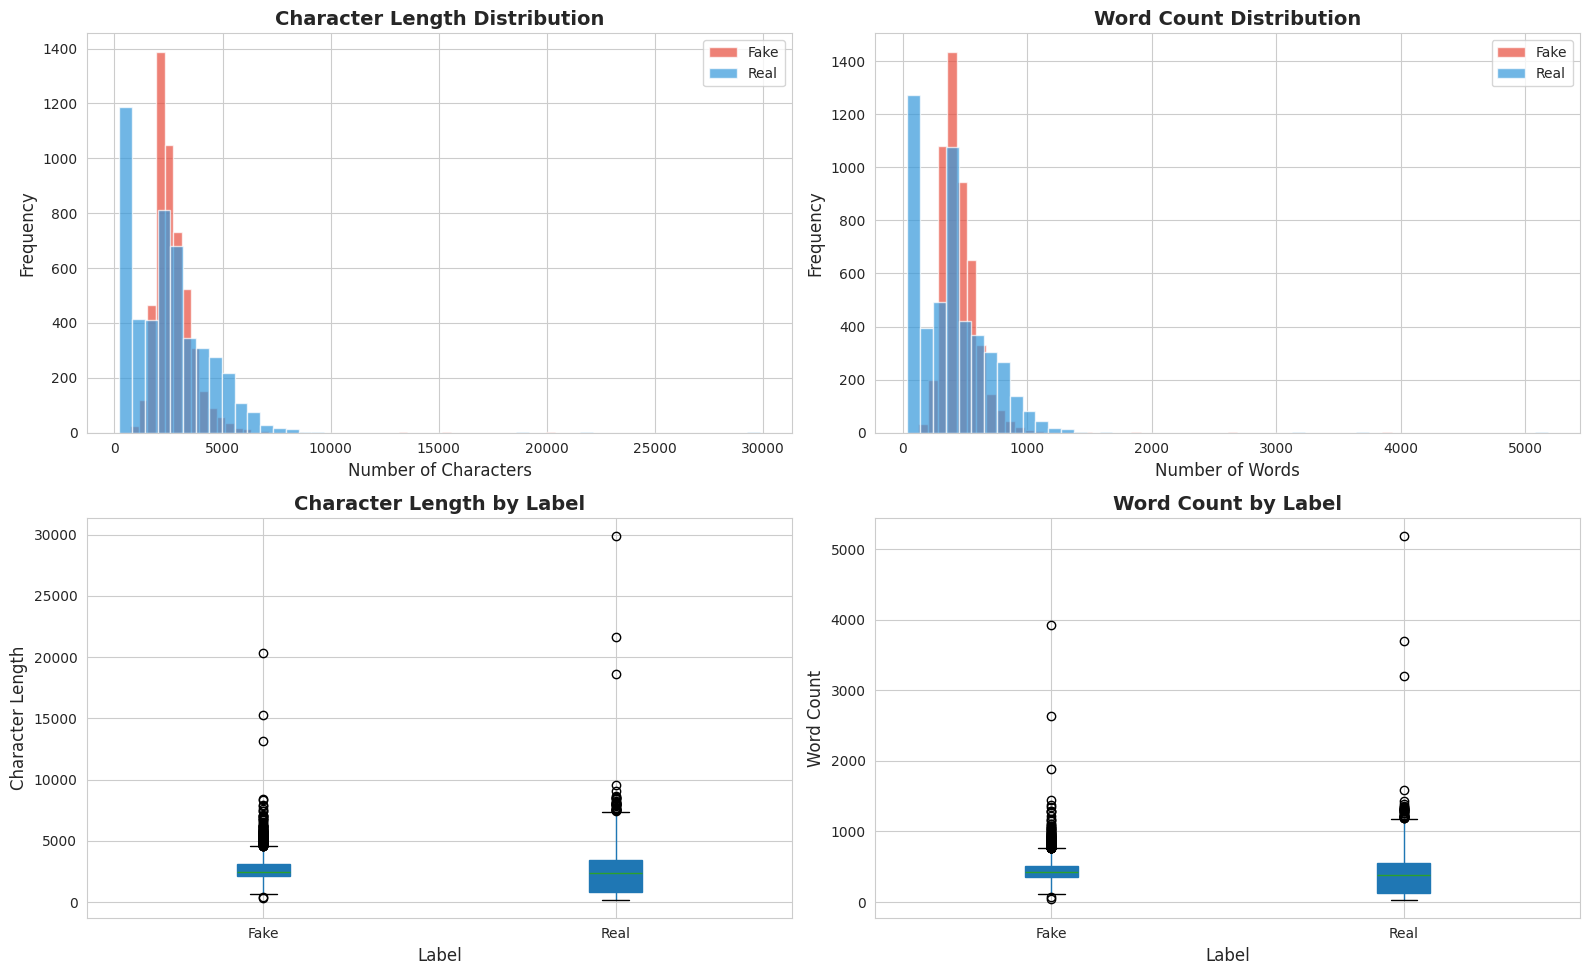


Average Character Length:
  Fake: 2691 characters
  Real: 2485 characters
  Difference: 207 characters

Average Word Count:
  Fake: 449 words
  Real: 396 words
  Difference: 53 words

→ Fake articles tend to be LONGER than Real articles


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax1 = axes[0, 0]
df[df['label'] == 'Fake']['text_length'].hist(bins=50, alpha=0.7, label='Fake', color='#e74c3c', ax=ax1)
df[df['label'] == 'Real']['text_length'].hist(bins=50, alpha=0.7, label='Real', color='#3498db', ax=ax1)
ax1.set_title('Character Length Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Characters', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.legend()

ax2 = axes[0, 1]
df[df['label'] == 'Fake']['word_count'].hist(bins=50, alpha=0.7, label='Fake', color='#e74c3c', ax=ax2)
df[df['label'] == 'Real']['word_count'].hist(bins=50, alpha=0.7, label='Real', color='#3498db', ax=ax2)
ax2.set_title('Word Count Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Words', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.legend()

ax3 = axes[1, 0]
df.boxplot(column='text_length', by='label', ax=ax3, patch_artist=True)
ax3.set_title('Character Length by Label', fontsize=14, fontweight='bold')
ax3.set_xlabel('Label', fontsize=12)
ax3.set_ylabel('Character Length', fontsize=12)
plt.suptitle('')  # Remove default title

ax4 = axes[1, 1]
df.boxplot(column='word_count', by='label', ax=ax4, patch_artist=True)
ax4.set_title('Word Count by Label', fontsize=14, fontweight='bold')
ax4.set_xlabel('Label', fontsize=12)
ax4.set_ylabel('Word Count', fontsize=12)
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

fake_avg_length = df[df['label'] == 'Fake']['text_length'].mean()
real_avg_length = df[df['label'] == 'Real']['text_length'].mean()
fake_avg_words = df[df['label'] == 'Fake']['word_count'].mean()
real_avg_words = df[df['label'] == 'Real']['word_count'].mean()

print(f"\nAverage Character Length:")
print(f"  Fake: {fake_avg_length:.0f} characters")
print(f"  Real: {real_avg_length:.0f} characters")
print(f"  Difference: {abs(fake_avg_length - real_avg_length):.0f} characters")

print(f"\nAverage Word Count:")
print(f"  Fake: {fake_avg_words:.0f} words")
print(f"  Real: {real_avg_words:.0f} words")
print(f"  Difference: {abs(fake_avg_words - real_avg_words):.0f} words")

if fake_avg_length > real_avg_length:
    print(f"\n→ Fake articles tend to be LONGER than Real articles")
else:
    print(f"\n→ Real articles tend to be LONGER than Fake articles")

### 5. Most Common Words Analysis

In [25]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return words

fake_words = []
real_words = []

for idx, row in df.iterrows():
    words = preprocess_text(row['Text'])
    if row['label'] == 'Fake':
        fake_words.extend(words)
    else:
        real_words.extend(words)

fake_word_counts = Counter(fake_words).most_common(20)
real_word_counts = Counter(real_words).most_common(20)

print("Top 20 Most Common Words in FAKE Articles:")
for word, count in fake_word_counts:
    print(f"  {word}: {count}")

print("\nTop 20 Most Common Words in REAL Articles:")
for word, count in real_word_counts:
    print(f"  {word}: {count}")

Top 20 Most Common Words in FAKE Articles:
  trump: 36841
  donald: 7707
  people: 6998
  president: 6549
  said: 6414
  would: 5689
  one: 5616
  via: 4813
  like: 4809
  image: 4718
  even: 4378
  white: 4254
  obama: 3550
  house: 3440
  also: 3301
  time: 3252
  realdonaldtrump: 3194
  images: 3113
  get: 3044
  going: 3002

Top 20 Most Common Words in REAL Articles:
  said: 22579
  trump: 17008
  would: 9036
  president: 8530
  house: 8519
  reuters: 6209
  republican: 5654
  tax: 5568
  trumps: 5236
  senate: 5192
  washington: 4871
  states: 4669
  white: 4625
  bill: 4052
  new: 4030
  donald: 3928
  state: 3846
  also: 3844
  could: 3621
  united: 3564


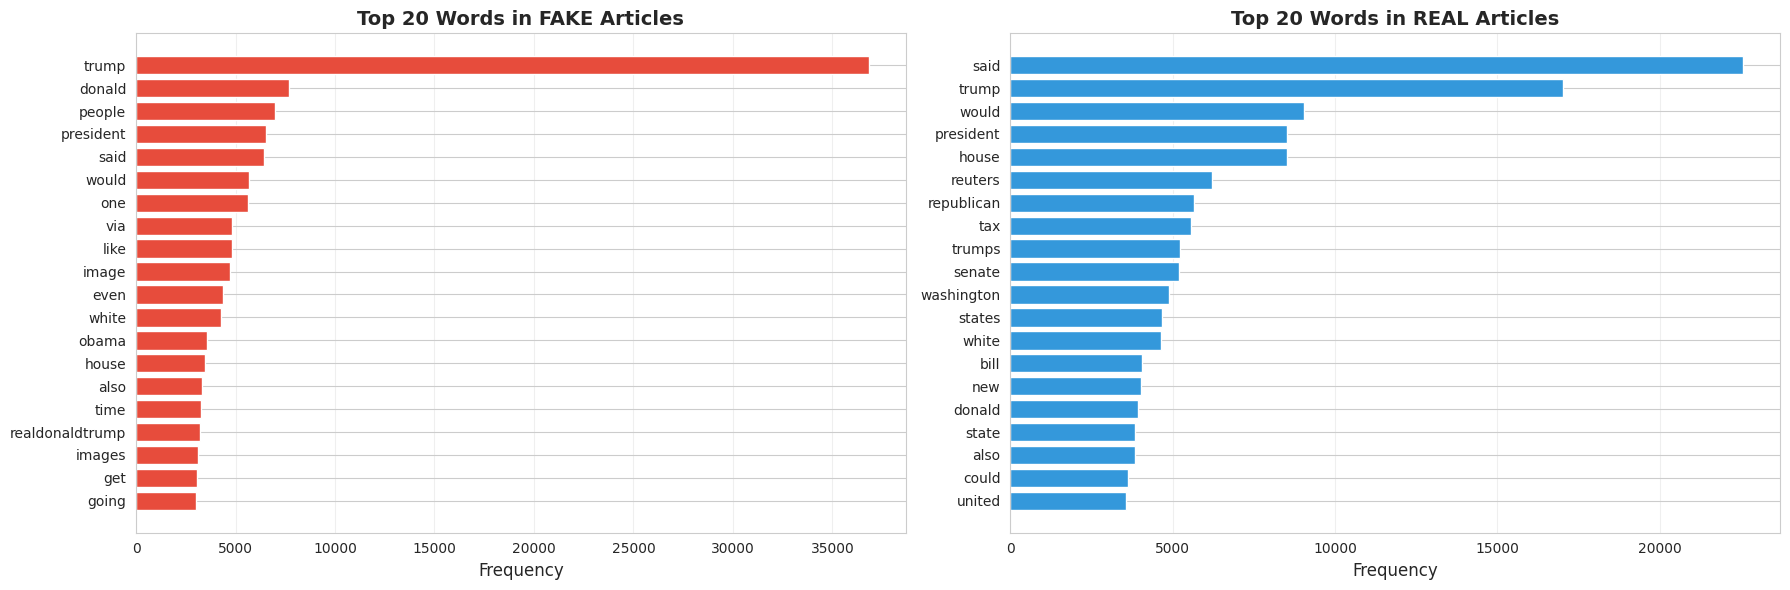

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Fake articles
ax1 = axes[0]
words_fake, counts_fake = zip(*fake_word_counts)
ax1.barh(range(len(words_fake)), counts_fake, color='#e74c3c')
ax1.set_yticks(range(len(words_fake)))
ax1.set_yticklabels(words_fake)
ax1.invert_yaxis()
ax1.set_xlabel('Frequency', fontsize=12)
ax1.set_title('Top 20 Words in FAKE Articles', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Real articles
ax2 = axes[1]
words_real, counts_real = zip(*real_word_counts)
ax2.barh(range(len(words_real)), counts_real, color='#3498db')
ax2.set_yticks(range(len(words_real)))
ax2.set_yticklabels(words_real)
ax2.invert_yaxis()
ax2.set_xlabel('Frequency', fontsize=12)
ax2.set_title('Top 20 Words in REAL Articles', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Key Findings Summary

In [27]:
print("KEY FINDINGS FROM EDA")

print(f"\n1. Dataset Overview:")
print(f"   - Total articles: {len(df):,}")
print(f"   - Fake articles: {label_counts['Fake']:,} ({(label_counts['Fake']/len(df)*100):.1f}%)")
print(f"   - Real articles: {label_counts['Real']:,} ({(label_counts['Real']/len(df)*100):.1f}%)")
print(f"   - Missing values: {df.isnull().sum().sum()}")
print(f"   - Duplicates: {duplicates}")

print(f"\n2. Text Length Analysis:")
if fake_avg_length > real_avg_length:
    print(f"   - Fake articles are LONGER on average")
    print(f"   - Fake: {fake_avg_length:.0f} chars, Real: {real_avg_length:.0f} chars")
else:
    print(f"   - Real articles are LONGER on average")
    print(f"   - Real: {real_avg_length:.0f} chars, Fake: {fake_avg_length:.0f} chars")

print(f"\n3. Vocabulary Analysis:")
print(f"   - Top fake words: {', '.join([w for w, c in fake_word_counts[:5]])}")
print(f"   - Top real words: {', '.join([w for w, c in real_word_counts[:5]])}")

print(f"\n4. Data Quality:")
if ratio > 0.8:
    print(f"   - Dataset is BALANCED (good for training)")
else:
    print(f"   - Dataset is IMBALANCED (may need resampling)")


KEY FINDINGS FROM EDA

1. Dataset Overview:
   - Total articles: 9,900
   - Fake articles: 5,000 (50.5%)
   - Real articles: 4,900 (49.5%)
   - Missing values: 0
   - Duplicates: 35

2. Text Length Analysis:
   - Fake articles are LONGER on average
   - Fake: 2691 chars, Real: 2485 chars

3. Vocabulary Analysis:
   - Top fake words: trump, donald, people, president, said
   - Top real words: said, trump, would, president, house

4. Data Quality:
   - Dataset is BALANCED (good for training)


In [28]:
# Save cleaned data for next notebook
df[['Text', 'label']].to_csv('data/cleaned_data.csv', index=False)
print("Cleaned data saved to: data/cleaned_data.csv")

Cleaned data saved to: data/cleaned_data.csv
